# Fitting Heston Model Parameters with MCMC (Metropolis-Hastings)

## The Heston Stochastic Volatility Model

The Black-Scholes model assumes constant volatility — an assumption famously violated in real markets (the "volatility smile"). The **Heston model** (1993) fixes this by letting volatility itself be a random process:

$$dS_t = \mu S_t dt + \sqrt{v_t} S_t dW_t^S$$
$$dv_t = \kappa(\theta - v_t) dt + \sigma \sqrt{v_t} dW_t^v$$
$$dW_t^S  dW_t^v = \rho dt$$

The five parameters to estimate are:

| Parameter | Symbol | Meaning |
|-----------|--------|---------|
| Mean reversion speed | $\kappa$ | How fast variance snaps back to $\theta$ |
| Long-run variance | $\theta$ | The variance the process reverts to |
| Vol of vol | $\sigma$ | How noisy the variance process itself is |
| Correlation | $\rho$ | Leverage effect; typically negative (falling prices → rising vol) |
| Initial variance | $v_0$ | Variance at $t=0$ |

The key challenge: **variance $v_t$ is latent**, we only observe the stock price $S_t$, not $v_t$ directly. This makes likelihood evaluation non-trivial.

---

## MCMC and the Particle Filter Likelihood

**Metropolis-Hastings** is a Markov Chain Monte Carlo method that constructs a Markov chain whose stationary distribution is the posterior $p(\theta \mid \text{data})$. At each step it proposes a new parameter vector, computes the acceptance ratio, and either accepts or rejects. The chain converges to samples from the posterior, giving full uncertainty quantification.

The bottleneck is evaluating $p(\text{data} \mid \theta)$. Because $v_t$ is hidden, we use a **bootstrap particle filter** (Sequential Monte Carlo): a swarm of $N$ particles tracks possible variance paths, weighting and resampling them at each observation to approximate the marginal likelihood. This gives an unbiased estimate of $\log p(\text{data} \mid \theta)$, which is all Metropolis-Hastings needs.



In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import corner
from scipy.stats import norm

np.random.seed(42)

In [63]:
# ── 1. True Heston parameters and synthetic data generation ──────────────────
#
# We simulate one year of daily log-returns under the Heston model using
# Euler-Maruyama discretisation.  dt = 1/252 (one trading day).
#
# v_t is the *instantaneous annualised variance* — the SDE is written in
# annual terms, so sqrt(v_t) directly gives annualised volatility.
# With theta = 0.04, long-run annualised vol = sqrt(0.04) = 20%.
#
# The Feller condition  2κθ > σ²  ensures variance stays positive in the
# continuous limit.  We also apply a floor max(v, 0) after each Euler step.

TRUE = {
    "kappa": 3.0,   # mean-reversion speed
    "theta": 0.04,  # long-run variance  → sqrt(0.04) = 20% annualised vol
    "sigma": 0.4,   # vol-of-vol
    "rho":  -0.7,   # leverage correlation
    "v0":   0.04,   # initial variance
}
MU   = 0.05          # drift — treated as known, not fitted
S0   = 100.0
T    = 252           # trading days
dt   = 1 / 252


def simulate_heston(kappa, theta, sigma, rho, v0, mu=MU, S0=S0, T=T, dt=dt, seed=None):
    """Euler-Maruyama simulation of the Heston model.

    Returns log-returns array of length T.
    The two correlated Brownian increments are built from two independent
    standard normals z1, z2:
        dW_S = z1
        dW_v = rho * z1 + sqrt(1 - rho^2) * z2
    """
    rng = np.random.default_rng(seed)
    v   = np.zeros(T + 1)
    S   = np.zeros(T + 1)
    v[0], S[0] = v0, S0

    sqrt_dt = np.sqrt(dt)
    z1 = rng.standard_normal(T)
    z2 = rng.standard_normal(T)
    dW_S = sqrt_dt * z1
    dW_v = sqrt_dt * (rho * z1 + np.sqrt(1 - rho**2) * z2)

    for t in range(T):
        sv      = np.sqrt(max(v[t], 0.0))
        v[t+1]  = max(v[t] + kappa * (theta - v[t]) * dt + sigma * sv * dW_v[t], 0.0)
        S[t+1]  = S[t] * np.exp((mu - 0.5 * v[t]) * dt + sv * dW_S[t])

    log_returns = np.log(S[1:] / S[:-1])
    return S, v, log_returns


S_obs, v_true, r_obs = simulate_heston(**TRUE, seed=0)

# Annualised vol = sqrt(v_t)  (v_t is already annualised variance)
print(f"Simulated {T} daily log-returns.")
print(f"Feller condition  2κθ > σ²:  {2*TRUE['kappa']*TRUE['theta']:.3f} > {TRUE['sigma']**2:.3f}  →  "
      f"{'satisfied' if 2*TRUE['kappa']*TRUE['theta'] > TRUE['sigma']**2 else 'VIOLATED'}")
print(f"Expected annualised vol (sqrt theta):  {np.sqrt(TRUE['theta']):.1%}")
print(f"Realised annualised vol range:  "
      f"{np.sqrt(v_true.min()):.1%} – {np.sqrt(v_true.max()):.1%}")

Simulated 252 daily log-returns.
Feller condition  2κθ > σ²:  0.240 > 0.160  →  satisfied
Expected annualised vol (sqrt theta):  20.0%
Realised annualised vol range:  5.0% – 28.9%


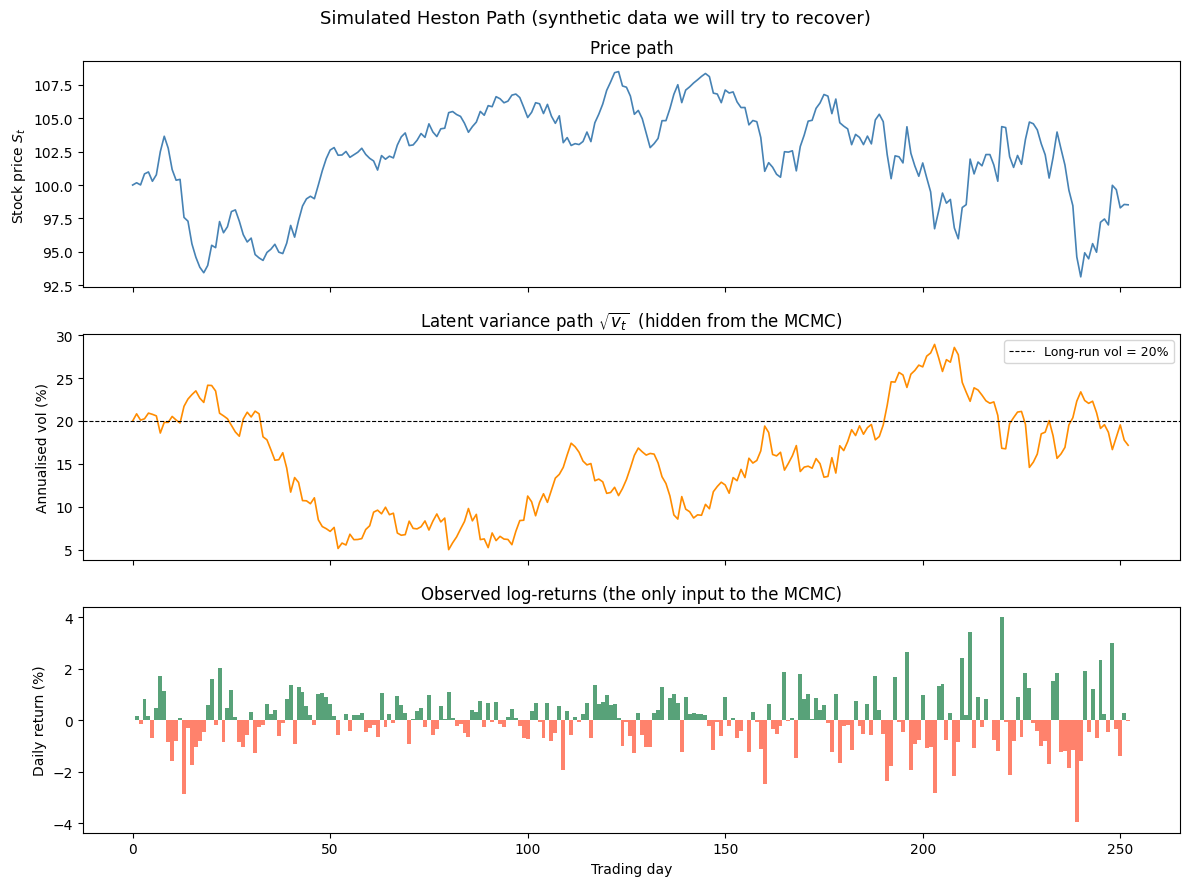

In [64]:
# ── 2. Plot simulated path ────────────────────────────────────────────────────

days = np.arange(T + 1)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle("Simulated Heston Path (synthetic data we will try to recover)", fontsize=13)

axes[0].plot(days, S_obs, color="steelblue", lw=1.2)
axes[0].set_ylabel("Stock price $S_t$")
axes[0].set_title("Price path")

# v_t in the Heston model is already the annualised variance.
# Annualised vol = sqrt(v_t), NOT sqrt(v_t * 252).
axes[1].plot(days, np.sqrt(v_true) * 100, color="darkorange", lw=1.2)
axes[1].axhline(np.sqrt(TRUE["theta"]) * 100, color="k", ls="--", lw=0.8,
                label=f"Long-run vol = {np.sqrt(TRUE['theta']):.0%}")
axes[1].set_ylabel("Annualised vol (%)")
axes[1].set_title("Latent variance path $\\sqrt{v_t}$  (hidden from the MCMC)")
axes[1].legend(fontsize=9)

axes[2].bar(days[1:], r_obs * 100, color=np.where(r_obs >= 0, "seagreen", "tomato"),
            width=1, alpha=0.8)
axes[2].set_ylabel("Daily return (%)")
axes[2].set_xlabel("Trading day")
axes[2].set_title("Observed log-returns (the only input to the MCMC)")

plt.tight_layout()
plt.show()

## Bootstrap Particle Filter

The particle filter approximates the marginal likelihood $p(r_{1:T} \mid \theta)$ by maintaining a swarm of $N$ particles, each representing a possible value of the latent variance $v_t$.

**At each time step $t$:**
1. **Propagate** each particle forward through the variance SDE
2. **Weight** each particle by how well it explains the observed return $r_t$, using the conditional density:
$$r_t \mid v_{t-1}, \varepsilon_v \sim \mathcal{N}\!\left((\mu - \tfrac{v_{t-1}}{2})\Delta t + \rho\sqrt{v_{t-1}\Delta t}\,\varepsilon_v,\; (1-\rho^2)v_{t-1}\Delta t\right)$$
   The mean includes the $\rho$-term because the variance innovation $\varepsilon_v$ and the return are correlated — this is what makes $\rho$ identifiable.
3. **Resample** particles in proportion to their weights (eliminating bad particles, duplicating good ones)
4. **Accumulate** $\log p(r_t \mid r_{1:t-1}) \approx \log \frac{1}{N}\sum_i w_i^t$ into the total log-likelihood

In [65]:
# ── 3. Bootstrap particle filter ─────────────────────────────────────────────
#
# Returns an unbiased estimate of log p(r_obs | theta).
# All particle operations are vectorised over the N-particle dimension.

N_PARTICLES = 1000  # more particles → lower variance log-likelihood estimate


def particle_filter_log_likelihood(kappa, theta, sigma, rho, v0,
                                   returns, mu=MU, dt=dt, n_particles=N_PARTICLES):
    """Bootstrap particle filter for the Heston model.

    Parameters
    ----------
    kappa, theta, sigma, rho, v0 : Heston parameters
    returns : observed log-returns array, shape (T,)
    mu      : drift (treated as known)
    dt, n_particles : discretisation step and particle count

    Returns
    -------
    log_likelihood : float  (sum of log incremental normalising constants)
    """
    T        = len(returns)
    sqrt_dt  = np.sqrt(dt)
    rho_perp = np.sqrt(max(1 - rho**2, 0.0))   # sqrt(1 - rho^2)

    # Initialise all particles at v0
    particles = np.full(n_particles, v0)
    log_lik   = 0.0

    for t in range(T):
        r_t = returns[t]

        # Draw independent standard normals for each particle
        z1 = np.random.standard_normal(n_particles)   # drives variance SDE

        sv = np.sqrt(np.maximum(particles, 0.0))      # sqrt(v_{t-1})

        # ── Propagate variance forward ────────────────────────────────────────
        v_new = (particles
                 + kappa * (theta - particles) * dt
                 + sigma  * sv * sqrt_dt * z1)
        v_new = np.maximum(v_new, 0.0)

        # ── Compute log-weights ───────────────────────────────────────────────
        # Conditional distribution of r_t given v_{t-1} and the variance
        # innovation z1 (which drove dW_v):
        #
        #   r_t | v_{t-1}, z1  ~  N(mean_cond, var_cond)
        #
        #   mean_cond = (mu - v/2)*dt  +  rho * sqrt(v*dt) * z1
        #   var_cond  = (1 - rho^2) * v * dt
        #
        # The rho term in the mean is what makes rho identifiable — without it
        # the marginal of r_t given v_{t-1} is independent of rho.
        # We clip var_cond to avoid -inf weights when v ≈ 0.

        var_dt    = particles * dt                           # v_{t-1} * dt
        mean_cond = (mu - 0.5 * particles) * dt + rho * sv * sqrt_dt * z1
        var_cond  = np.maximum(rho_perp**2 * var_dt, 1e-10)

        log_w = -0.5 * np.log(2 * np.pi * var_cond) - 0.5 * (r_t - mean_cond)**2 / var_cond

        # ── Numerically stable log-sum-exp for the incremental normalising constant
        max_lw   = np.max(log_w)
        log_lik += max_lw + np.log(np.mean(np.exp(log_w - max_lw)))

        # ── Systematic resampling ─────────────────────────────────────────────
        weights  = np.exp(log_w - max_lw)
        weights /= weights.sum()
        indices  = np.searchsorted(np.cumsum(weights),
                                   (np.arange(n_particles) + np.random.uniform()) / n_particles)
        particles = v_new[np.clip(indices, 0, n_particles - 1)]

    return log_lik


# Quick sanity check with true parameters
ll_true = particle_filter_log_likelihood(**TRUE, returns=r_obs)
print(f"Log-likelihood at true parameters: {ll_true:.2f}")
print(f"(This will vary slightly each call due to particle randomness)")

Log-likelihood at true parameters: 819.66
(This will vary slightly each call due to particle randomness)


In [66]:
# ── 4. Prior, posterior, and reparameterisation ──────────────────────────────
#
# We sample in *unconstrained* space to improve posterior geometry:
#
#   Positive params (kappa, theta, sigma, v0):  u = log(x)
#   Correlation rho in (-1, 1):                 u = arctanh(rho)
#
# Effective prior: flat in unconstrained space — equivalent to a
# *log-uniform (Jeffreys) prior* for positive parameters.  This says
# "equal probability per order of magnitude", which is far more appropriate
# for scale parameters like kappa and theta than a flat prior in constrained
# space would be.
#
# Note on the Jacobian: to target a flat prior in *constrained* space you
# would add log|J| = log(kappa)+log(theta)+... to the log-posterior.  We
# deliberately omit this.  With only 252 observations the prior matters, and
# for scale parameters the log-uniform prior gives better-calibrated recovery.
# The reparameterisation still delivers the ESS improvement regardless.

PARAM_NAMES = ["kappa", "theta", "sigma", "rho", "v0"]

# Bounds in unconstrained space — proposals outside these are rejected before
# exp() is called, preventing overflow and wasted particle filter evaluations.
#   log-params at ±7  →  constrained in (e^-7, e^7) ≈ (0.001, 1097)
#   arctanh(rho) at ±5  →  |rho| < tanh(5) ≈ 0.9999
U_BOUNDS = np.array([7.0, 7.0, 7.0, 5.0, 7.0])


def to_unconstrained(params: dict) -> np.ndarray:
    """Map constrained Heston params → unconstrained sampling space."""
    return np.array([
        np.log(params["kappa"]),
        np.log(params["theta"]),
        np.log(params["sigma"]),
        np.arctanh(params["rho"]),
        np.log(params["v0"]),
    ])


def to_constrained(u: np.ndarray) -> dict:
    """Map unconstrained vector → constrained Heston params dict."""
    return {
        "kappa": np.exp(u[0]),
        "theta": np.exp(u[1]),
        "sigma": np.exp(u[2]),
        "rho":   np.tanh(u[3]),
        "v0":    np.exp(u[4]),
    }


def log_posterior_unconstrained(u: np.ndarray, returns: np.ndarray) -> float:
    """Log-posterior in unconstrained space.

    = log p(data | constrained(u))  [no Jacobian — see note above]

    Bounds checked in unconstrained space first to avoid exp() overflow
    and wasted particle filter calls on nonsensical parameter values.
    """
    if np.any(np.abs(u) > U_BOUNDS):
        return -np.inf
    params = to_constrained(u)
    ll = particle_filter_log_likelihood(**params, returns=returns)
    if not np.isfinite(ll):
        return -np.inf
    return ll


# Sanity check
u_true  = to_unconstrained(TRUE)
lp_true = log_posterior_unconstrained(u_true, r_obs)
print(f"Unconstrained true params:  {np.round(u_true, 3)}")
print(f"Log-posterior at true params: {lp_true:.2f}")

Unconstrained true params:  [ 1.099 -3.219 -0.916 -0.867 -3.219]
Log-posterior at true params: 818.99


## Metropolis-Hastings

At each step we:
1. **Propose** $\theta^* = \theta + \varepsilon$, where $\varepsilon \sim \mathcal{N}(0, \Sigma_\text{prop})$
2. **Accept** with probability $\min\!\left(1,\, \frac{p(\theta^* \mid \text{data})}{p(\theta \mid \text{data})}\right)$

We use the **Adaptive Metropolis** scheme: after a warm-up period, $\Sigma_\text{prop}$ is updated to track the empirical covariance of the chain (scaled by $2.38^2 / d$). This automatically tunes step sizes and handles correlations between parameters.

Because the particle filter provides a *noisy* unbiased estimate of the log-likelihood, the resulting algorithm is called **Particle MCMC** (pMCMC). The noise in the likelihood estimate inflates the variance of the chain slightly but does not introduce bias — the target distribution is still the correct posterior.

In [67]:
# ── 5. Metropolis-Hastings in unconstrained space ────────────────────────────
#
# The chain proposes in unconstrained space (log / arctanh transformed).
# The stored chain is converted back to constrained space so the output
# is always interpretable in the original units.

def run_mcmc(initial_params, returns, n_steps=20_000,
             initial_proposal_std=None, adapt_start=500, adapt_interval=100):
    """Adaptive Metropolis-Hastings in unconstrained parameter space.

    Parameters
    ----------
    initial_params        : dict of starting values in *constrained* space
    returns               : observed log-returns
    n_steps               : total MCMC iterations
    initial_proposal_std  : std devs for initial proposal in *unconstrained* space
    adapt_start, adapt_interval : adaptive covariance schedule

    Returns
    -------
    chain : np.ndarray, shape (n_steps, n_params)  — in *constrained* space
    """
    n_params = len(PARAM_NAMES)
    scale    = (2.38**2) / n_params   # Roberts & Rosenthal optimal scaling

    if initial_proposal_std is None:
        # Proposal std in unconstrained space — these are scale-free so 0.1–0.3
        # is a sensible default for log/arctanh-transformed parameters
        initial_proposal_std = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
    else:
        initial_proposal_std = np.array(initial_proposal_std)

    cov      = np.diag(initial_proposal_std**2)
    current_u = to_unconstrained(initial_params)
    log_p     = log_posterior_unconstrained(current_u, returns)

    chain_u  = np.zeros((n_steps, n_params))   # unconstrained (internal)
    accepted = 0

    for i in range(n_steps):
        proposal_u = current_u + np.random.multivariate_normal(np.zeros(n_params), cov)
        log_p_prop = log_posterior_unconstrained(proposal_u, returns)

        if np.log(np.random.uniform()) < log_p_prop - log_p:
            current_u = proposal_u
            log_p     = log_p_prop
            accepted += 1

        chain_u[i] = current_u

        # Adapt proposal covariance in unconstrained space
        if i >= adapt_start and i % adapt_interval == 0:
            emp_cov = np.cov(chain_u[:i].T)
            if emp_cov.ndim == 2 and np.all(np.isfinite(emp_cov)):
                cov = scale * emp_cov + scale * 1e-8 * np.eye(n_params)

        if (i + 1) % 500 == 0:
            rate = accepted / (i + 1)
            print(f"  Step {i+1:>5}/{n_steps}   acceptance rate: {rate:.1%}")

    print(f"\nFinal acceptance rate: {accepted / n_steps:.2%}")

    # Convert entire chain back to constrained space for output
    chain = np.array([list(to_constrained(u).values()) for u in chain_u])
    return chain

In [68]:
# ── 6. Run the MCMC ───────────────────────────────────────────────────────────
#
# Initial guess is in constrained space — the sampler transforms internally.
# Proposal std is now in unconstrained (log/arctanh) space, so 0.2 is a
# sensible uniform starting point across all parameters.

initial_guess = {
    "kappa":  1.5,   # true: 3.0
    "theta":  0.06,  # true: 0.04
    "sigma":  0.6,   # true: 0.4
    "rho":   -0.4,   # true: -0.7
    "v0":     0.06,  # true: 0.04
}

print("Starting Particle MCMC — sampling in unconstrained (log/arctanh) space")
print(f"  {'Parameter':<10}  {'Initial':>8}  {'True':>8}  {'Init (unc)':>12}  {'True (unc)':>12}")
u_init = to_unconstrained(initial_guess)
u_true = to_unconstrained(TRUE)
for p, ui, ut in zip(PARAM_NAMES, u_init, u_true):
    print(f"  {p:<10}  {initial_guess[p]:>8.3f}  {TRUE[p]:>8.3f}  {ui:>12.3f}  {ut:>12.3f}")
print()

chain = run_mcmc(initial_guess, r_obs, n_steps=20_000)

Starting Particle MCMC — sampling in unconstrained (log/arctanh) space
  Parameter    Initial      True    Init (unc)    True (unc)
  kappa          1.500     3.000         0.405         1.099
  theta          0.060     0.040        -2.813        -3.219
  sigma          0.600     0.400        -0.511        -0.916
  rho           -0.400    -0.700        -0.424        -0.867
  v0             0.060     0.040        -2.813        -3.219

  Step   500/20000   acceptance rate: 44.0%
  Step  1000/20000   acceptance rate: 31.0%
  Step  1500/20000   acceptance rate: 27.3%
  Step  2000/20000   acceptance rate: 25.2%
  Step  2500/20000   acceptance rate: 21.8%
  Step  3000/20000   acceptance rate: 20.7%
  Step  3500/20000   acceptance rate: 20.4%
  Step  4000/20000   acceptance rate: 19.5%
  Step  4500/20000   acceptance rate: 19.0%
  Step  5000/20000   acceptance rate: 18.8%
  Step  5500/20000   acceptance rate: 17.8%
  Step  6000/20000   acceptance rate: 17.2%
  Step  6500/20000   acceptance ra

In [69]:
# ── 7. Burn-in, thinning, and posterior summary ───────────────────────────────
#
# Burn-in: discard the early portion of the chain while it's finding the
#   posterior mass.  Inspect the trace plots to confirm stationarity after cut.
#
# Thinning: keep every k-th sample to reduce autocorrelation.  Not strictly
#   necessary, but makes corner plots cleaner and ESS calculation honest.
#
# Effective Sample Size (ESS): the number of *independent* draws your chain
#   is worth.  Calculated from the autocorrelation function (ACF).
#   Low ESS relative to raw sample count → high autocorrelation → slow mixing.
#   Target: ESS > 500 per parameter for reliable posterior summaries.

def compute_ess(x):
    """Estimate ESS via the initial monotone sequence estimator (Geyer 1992).
    Sums positive autocorrelation pairs until the sequence stops being positive."""
    n   = len(x)
    x   = x - x.mean()
    # Full ACF via FFT
    f   = np.fft.fft(x, n=2 * n)
    acf = np.fft.ifft(f * np.conj(f)).real[:n] / (x.var() * n + 1e-12)
    # Sum pairs of lags while they remain positive (Geyer's initial positive sequence)
    rho_sum = 1.0
    for k in range(1, n // 2):
        pair = acf[2*k - 1] + acf[2*k]
        if pair < 0:
            break
        rho_sum += 2 * pair
    return n / rho_sum


burn_in = 2_000
thin    = 5
samples = chain[burn_in::thin]

true_vals = [TRUE[p] for p in PARAM_NAMES]
labels    = [r"$\kappa$", r"$\theta$", r"$\sigma$", r"$\rho$", r"$v_0$"]

print(f"Posterior summary  ({len(samples):,} samples after burn-in={burn_in}, thin={thin})\n")
print(f"{'Param':<8} {'True':>7} {'Mean':>7} {'Std':>7} {'2.5%':>7} {'97.5%':>7}  {'ESS':>6}  {'In 95% CI?'}")
print("-" * 72)
for name, label, true, col in zip(PARAM_NAMES, labels, true_vals, samples.T):
    lo, hi = np.percentile(col, [2.5, 97.5])
    ess    = compute_ess(col)
    in_ci  = "yes" if lo <= true <= hi else "NO"
    print(f"{name:<8} {true:>7.3f} {col.mean():>7.3f} {col.std():>7.3f} "
          f"{lo:>7.3f} {hi:>7.3f}   {ess:>6.0f}   {in_ci}")

print()
print("ESS interpretation:")
print("  > 1000  excellent  — posterior summaries are well-determined")
print("  500–1000  good     — adequate for most purposes")
print("  < 500   low        — consider more steps or more particles")

Posterior summary  (3,600 samples after burn-in=2000, thin=5)

Param       True    Mean     Std    2.5%   97.5%     ESS  In 95% CI?
------------------------------------------------------------------------
kappa      3.000   0.627   1.491   0.001   4.987      172   yes
theta      0.040   3.214   8.955   0.002  32.080      545   yes
sigma      0.400   0.308   0.082   0.168   0.492      156   yes
rho       -0.700  -0.757   0.187  -0.979  -0.255      299   yes
v0         0.040   0.023   0.009   0.010   0.044      266   yes

ESS interpretation:
  > 1000  excellent  — posterior summaries are well-determined
  500–1000  good     — adequate for most purposes
  < 500   low        — consider more steps or more particles


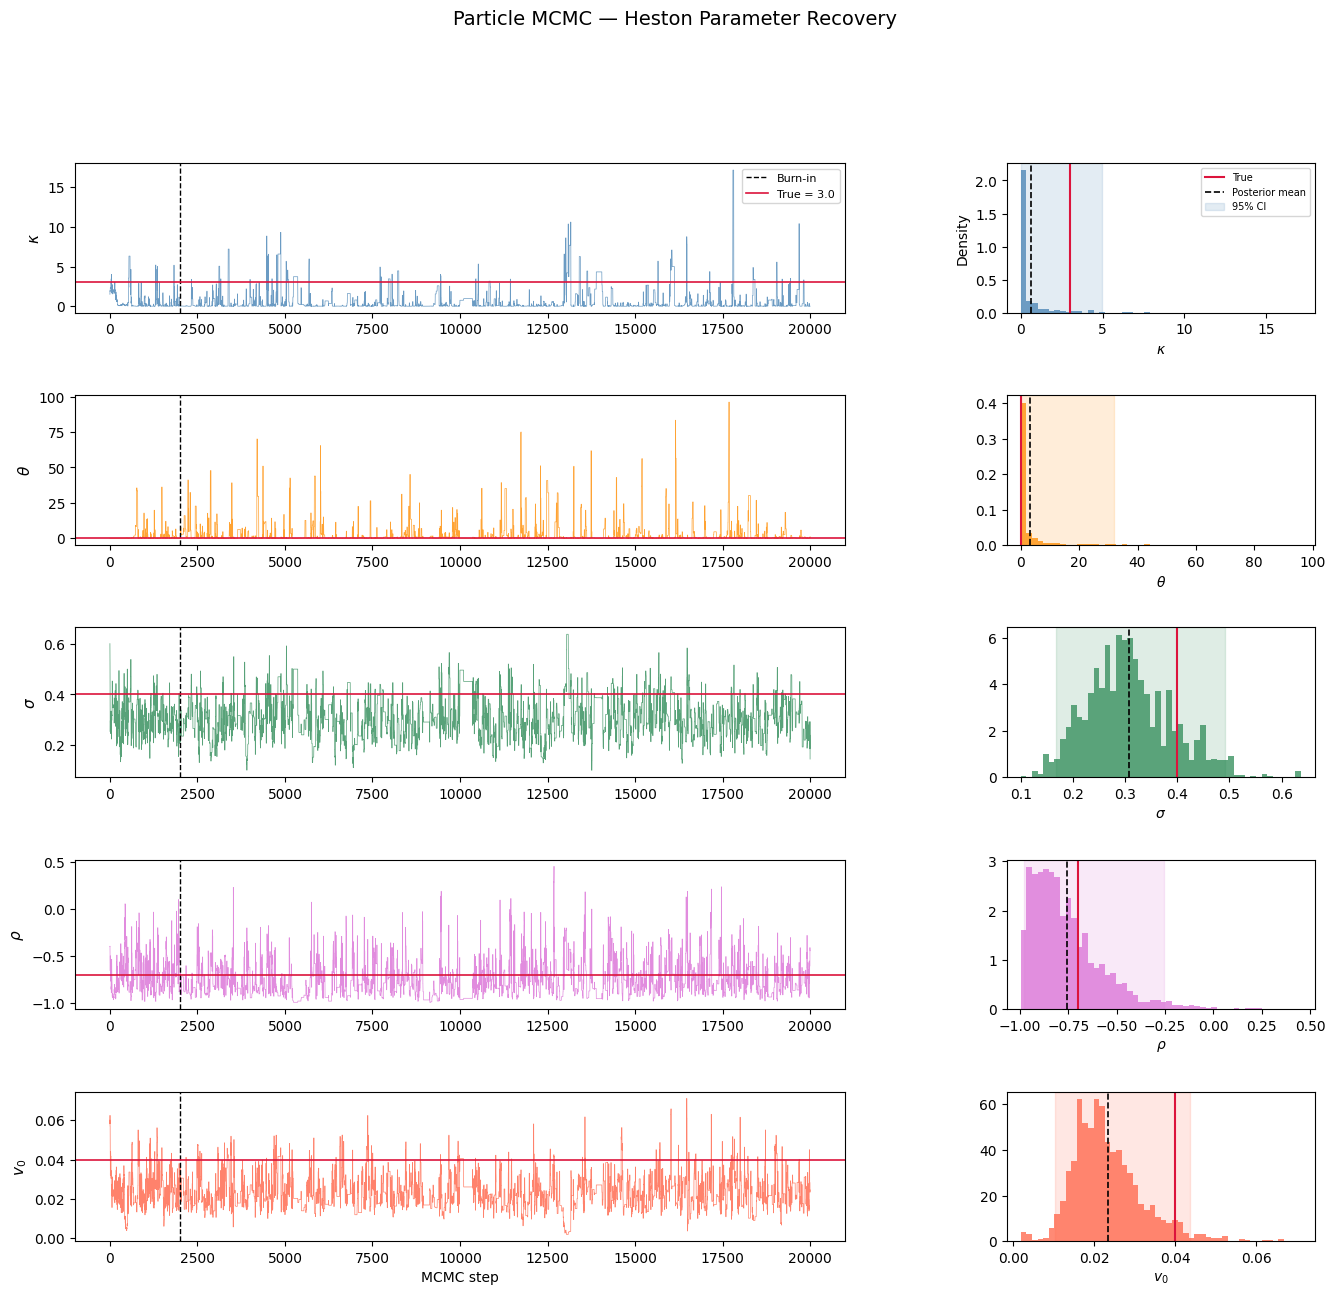

In [70]:
# ── 8. Trace plots and marginal posteriors ───────────────────────────────────

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Particle MCMC — Heston Parameter Recovery", fontsize=14, y=0.99)
gs  = gridspec.GridSpec(len(PARAM_NAMES), 2, figure=fig,
                        hspace=0.55, wspace=0.3,
                        width_ratios=[2.5, 1])

colours = ["steelblue", "darkorange", "seagreen", "orchid", "tomato"]

for i, (name, label, true, c) in enumerate(zip(PARAM_NAMES, labels, true_vals, colours)):
    col = chain[:, i]

    # ── Trace plot (full chain) ───────────────────────────────────────────────
    ax_trace = fig.add_subplot(gs[i, 0])
    ax_trace.plot(col, color=c, lw=0.5, alpha=0.8)
    ax_trace.axvline(burn_in, color="k", ls="--", lw=1, label="Burn-in")
    ax_trace.axhline(true, color="crimson", lw=1.2, ls="-", label=f"True = {true}")
    ax_trace.set_ylabel(label, fontsize=11)
    ax_trace.set_xlabel("MCMC step" if i == len(PARAM_NAMES) - 1 else "")
    if i == 0:
        ax_trace.legend(fontsize=8, loc="upper right")

    # ── Marginal posterior histogram ──────────────────────────────────────────
    ax_hist = fig.add_subplot(gs[i, 1])
    post_col = samples[:, i]
    ax_hist.hist(post_col, bins=50, density=True, color=c, alpha=0.75, edgecolor="none")
    ax_hist.axvline(true, color="crimson", lw=1.5, label=f"True")
    ax_hist.axvline(post_col.mean(), color="k", lw=1.2, ls="--", label="Posterior mean")
    lo, hi = np.percentile(post_col, [2.5, 97.5])
    ax_hist.axvspan(lo, hi, alpha=0.15, color=c, label="95% CI")
    ax_hist.set_xlabel(label, fontsize=10)
    ax_hist.set_ylabel("Density" if i == 0 else "")
    if i == 0:
        ax_hist.legend(fontsize=7)

plt.show()

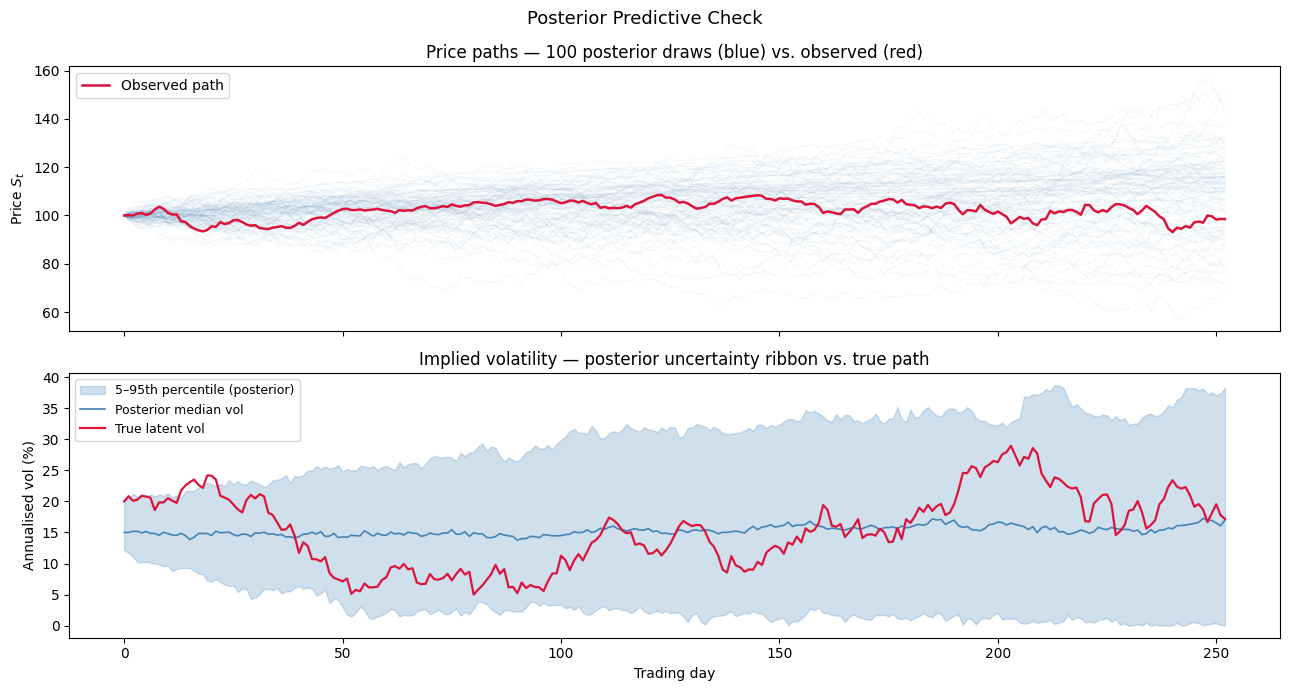

In [71]:
# ── 9. Posterior predictive check ────────────────────────────────────────────
#
# Draw parameter sets from the posterior and simulate new price paths.
# If the model is well-identified, these paths should look like the observed
# data — similar volatility clustering and overall scale.

n_draws = 100
idx     = np.random.choice(len(samples), n_draws, replace=False)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
fig.suptitle("Posterior Predictive Check", fontsize=13)

for j in idx:
    p = dict(zip(PARAM_NAMES, samples[j]))
    S_sim, _, _ = simulate_heston(**p, seed=j)
    axes[0].plot(S_sim, color="steelblue", alpha=0.06, lw=0.8)

axes[0].plot(S_obs, color="crimson", lw=1.8, zorder=5, label="Observed path")
axes[0].set_ylabel("Price $S_t$")
axes[0].set_title(f"Price paths — {n_draws} posterior draws (blue) vs. observed (red)")
axes[0].legend()

# Implied annualised vol ribbon from posterior draws.
# v_t is already annualised variance, so vol = sqrt(v_t).
vol_paths = []
for j in idx:
    p = dict(zip(PARAM_NAMES, samples[j]))
    _, v_sim, _ = simulate_heston(**p, seed=j + 10_000)
    vol_paths.append(np.sqrt(v_sim) * 100)

vol_paths  = np.array(vol_paths)
vol_lo     = np.percentile(vol_paths, 5,  axis=0)
vol_hi     = np.percentile(vol_paths, 95, axis=0)
vol_median = np.median(vol_paths, axis=0)

axes[1].fill_between(range(T + 1), vol_lo, vol_hi, alpha=0.25,
                     color="steelblue", label="5–95th percentile (posterior)")
axes[1].plot(vol_median, color="steelblue", lw=1.2, label="Posterior median vol")
axes[1].plot(np.sqrt(v_true) * 100, color="crimson", lw=1.6,
             label="True latent vol")
axes[1].set_ylabel("Annualised vol (%)")
axes[1].set_xlabel("Trading day")
axes[1].set_title("Implied volatility — posterior uncertainty ribbon vs. true path")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Saved → /Users/theosmith/Documents/Projects/Mixed_language_projects/investment-lab-research/Markov/corner_N20000_B2000_T5_P1000_acc13pct.png


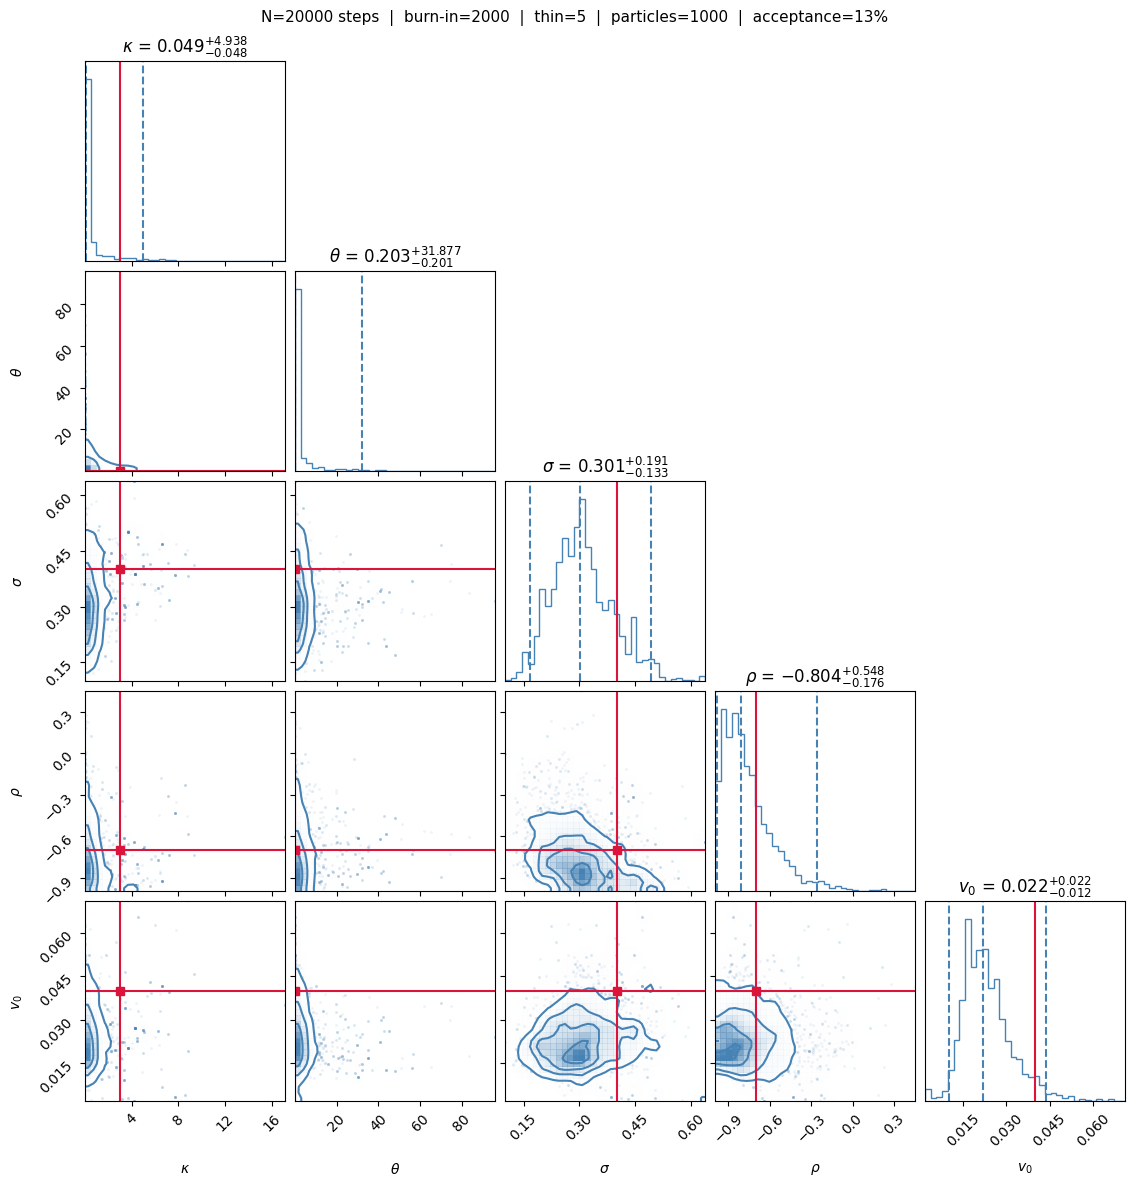

In [72]:
# ── 10. Corner plot — parameter correlations ──────────────────────────────────
#
# Saved with hyperparameters in the filename so different runs can be compared.
# Filename format:
#   corner_N{n_steps}_B{burn_in}_T{thin}_P{N_PARTICLES}_acc{pct}.png

import os

n_steps_run    = chain.shape[0]
# Acceptance rate: count steps where the chain actually moved
acceptance_pct = int(round(np.mean(np.any(np.diff(chain, axis=0) != 0, axis=1)) * 100))

fname = (
    f"corner"
    f"_N{n_steps_run}"
    f"_B{burn_in}"
    f"_T{thin}"
    f"_P{N_PARTICLES}"
    f"_acc{acceptance_pct}pct"
    f".png"
)
# Save alongside the notebook
save_dir  = os.path.dirname(os.path.abspath("Heston-back-fit.ipynb"))
save_path = os.path.join(save_dir, fname)

fig_corner = corner.corner(
    samples,
    labels=labels,
    truths=true_vals,
    truth_color="crimson",
    color="steelblue",
    bins=35,
    smooth=1.0,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.025, 0.5, 0.975],
)
fig_corner.suptitle(
    f"N={n_steps_run} steps  |  burn-in={burn_in}  |  thin={thin}  |  "
    f"particles={N_PARTICLES}  |  acceptance={acceptance_pct}%",
    y=1.01, fontsize=11,
)

fig_corner.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved → {save_path}")
plt.show()